In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

In [5]:
data = pd.read_csv("/content/WineQT.csv", sep=',')


In [6]:
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
print(data.info())
print("\nDataset Description:")
print(data.describe())

Dataset Shape: (1143, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None

Dataset Description:
       

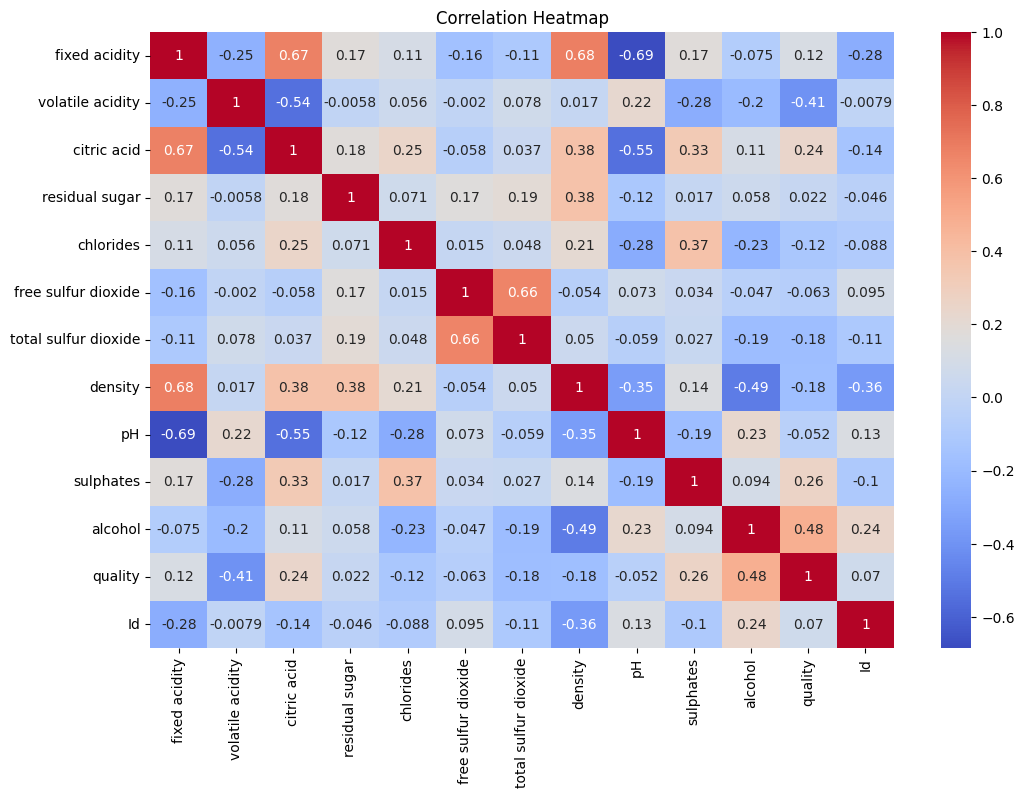

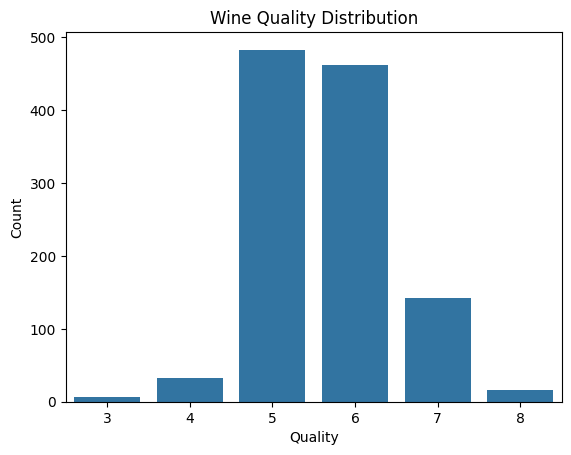

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.countplot(x='quality', data=data)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [8]:
X = data.drop('quality', axis=1)
y = data['quality']
y = y.apply(lambda x: 1 if x >= 7 else 0)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


--- Random Forest Classifier ---
Accuracy: 0.9344978165938864
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       201
           1       0.78      0.64      0.71        28

    accuracy                           0.93       229
   macro avg       0.87      0.81      0.83       229
weighted avg       0.93      0.93      0.93       229



In [12]:
sgd = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)
sgd_pred = sgd.predict(X_test)

print("\n--- SGD Classifier ---")
print("Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))


--- SGD Classifier ---
Accuracy: 0.834061135371179
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       201
           1       0.35      0.43      0.39        28

    accuracy                           0.83       229
   macro avg       0.64      0.66      0.65       229
weighted avg       0.85      0.83      0.84       229



In [13]:
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

print("\n--- Support Vector Classifier ---")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))


--- Support Vector Classifier ---
Accuracy: 0.8995633187772926
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.69      0.32      0.44        28

    accuracy                           0.90       229
   macro avg       0.80      0.65      0.69       229
weighted avg       0.89      0.90      0.88       229



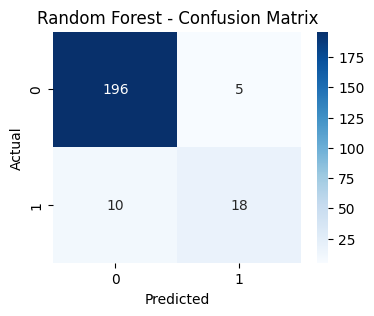

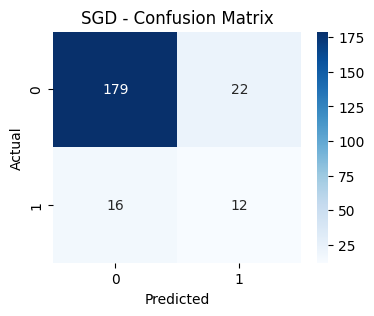

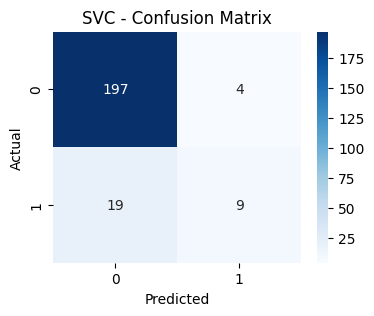

In [14]:
models = {
    "Random Forest": rf_pred,
    "SGD": sgd_pred,
    "SVC": svc_pred
}

for model_name, predictions in models.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        confusion_matrix(y_test, predictions),
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()